In [1]:
import numpy as np
import matplotlib.pyplot as plt

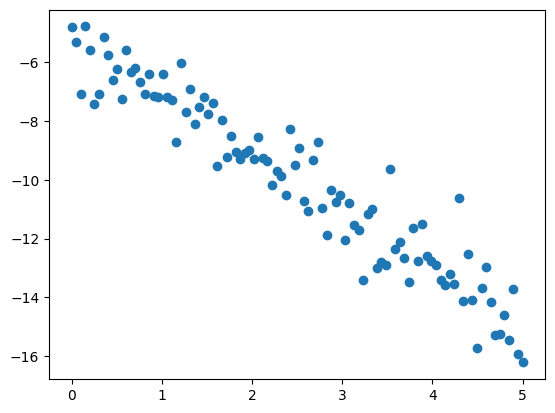

In [2]:
# m=5, c=7
X = np.linspace(0, 5, 100)
y = -2 * X + (-5) + 1* np.random.randn(X.size)
losses = []
trajectory = []
plt.scatter(X, y)
# plt.ylim(0, 40)

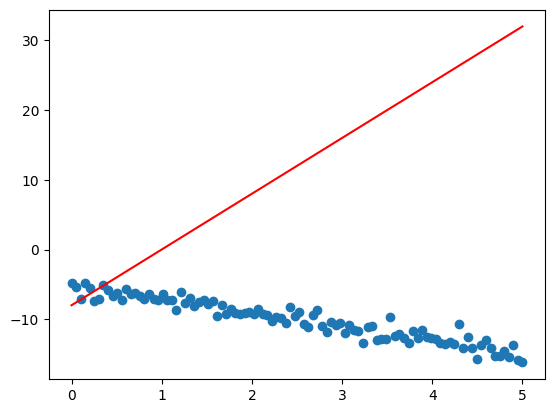

In [3]:
# gradient descent
m = 8
c = -8

plt.scatter(X, y)
plt.plot(X, m*X + c, color='red')


In [4]:
# loss function, least square
def loss_function(m, c, X, y):
    N = len(X)
    return (1/N) * np.sum((y - (m*X + c))**2)

loss_function(m, c, X, y)

697.5221002834647

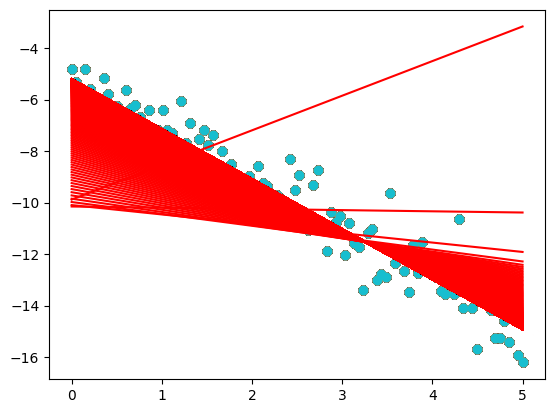

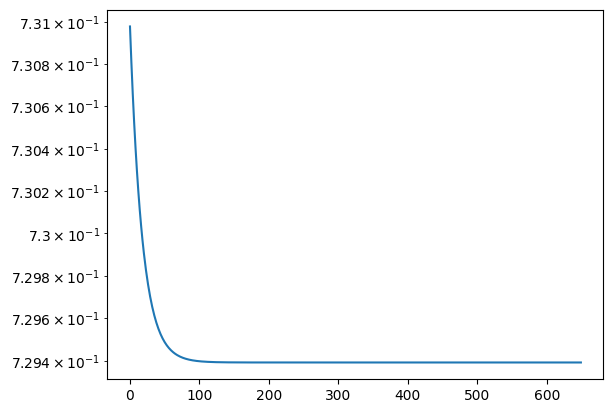

In [5]:
eta = 0.03

def dldm(m, c, X, y):
    N = len(X)
    dldm_val =  (-2/N) * np.sum(X * (y - (m*X + c)))
    # print(f"dldm: {dldm_val}")
    return dldm_val

def dldc(m, c, X, y):
    N = len(X)
    dldc_val = (-2/N) * np.sum(y - (m*X + c))
    # print(f"dldc: {dldc_val}")
    return dldc_val

for _ in range(800):
    losses.append(loss_function(m, c, X, y))
    trajectory.append((m, c))
    m1 = m - eta * dldm(m, c, X, y)
    c1 = c - eta * dldc(m, c, X, y)
    m, c = m1, c1



    m1 = m - eta * dldm(m, c, X, y)
    c1 = c - eta * dldc(m, c, X, y)

    m, c = m1, c1

    # print(f"m: {m}, c: {c}")

    plt.plot(X, m*X + c, color='red')
    plt.scatter(X, y)
plt.show()

plt.plot(losses[150:])
plt.yscale('log')
plt.show()

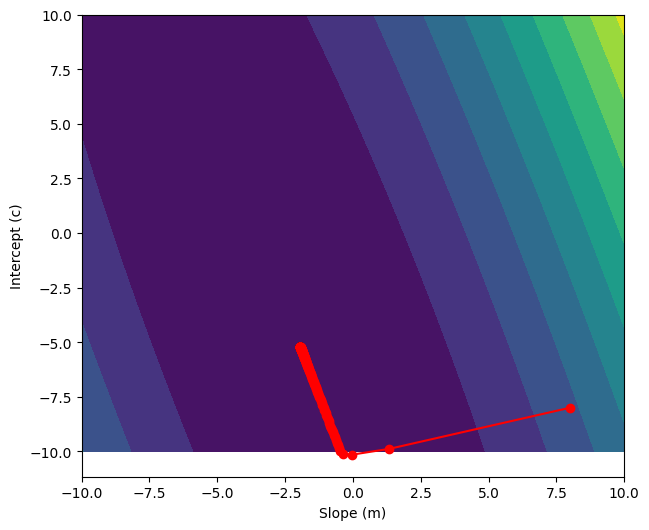

In [6]:
m_values = np.linspace(-10, 10, 100)
c_values = np.linspace(-10, 10, 100)

loss_surface = np.zeros((len(c_values), len(m_values)))

for i, c_temp in enumerate(c_values):
    for j, m_temp in enumerate(m_values):
        y_hat = m_temp*X + c_temp
        loss_surface[i,j] = np.mean((y-y_hat)**2)

plt.figure(figsize=(7,6))

CS = plt.contourf(
        m_values,
        c_values,
        loss_surface,
        levels=10)

plt.xlabel("Slope (m)")
plt.ylabel("Intercept (c)")

traj = np.array(trajectory)

plt.plot(
    traj[:,0],
    traj[:,1],
    'ro-')

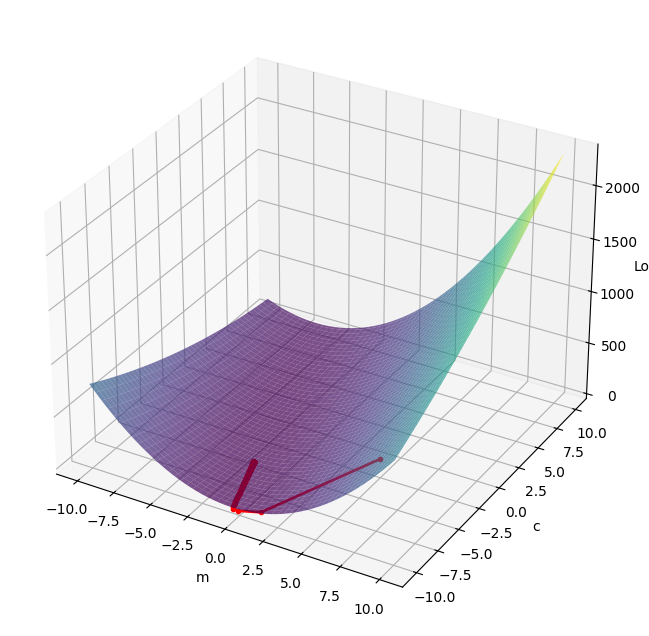

In [7]:
# convert the above to a 3D plot, m and c on the x and y axes, loss on the z axis, and the trajectory of the gradient descent on the surface
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# Create a 3D plot of the loss surface and the trajectory of the gradient descent
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create a meshgrid for m and c values
m_values = np.linspace(-10, 10, 100)
c_values = np.linspace(-10, 10, 100)
M, C = np.meshgrid(m_values, c_values)

# Calculate the loss surface
Loss_surface = np.zeros(M.shape)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        y_hat = M[i, j] * X + C[i, j]
        Loss_surface[i, j] = np.mean((y - y_hat) ** 2)

# Plot the loss surface
ax.plot_surface(M, C, Loss_surface, cmap='viridis', alpha=0.7)

# Plot the trajectory of the gradient descent
traj = np.array(trajectory)
traj_losses = np.array(losses)
ax.plot(traj[:, 0], traj[:, 1], traj_losses, color='r', marker='o', markersize=3, linewidth=2)

# Set labels
ax.set_xlabel('m')
ax.set_ylabel('c')
ax.set_zlabel('Loss')

plt.show()

In [8]:
m,c

(-1.9407542554827872, -5.210788809351055)

Day 2: With torch to just do the grad calculation. Nothing Else.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import torch

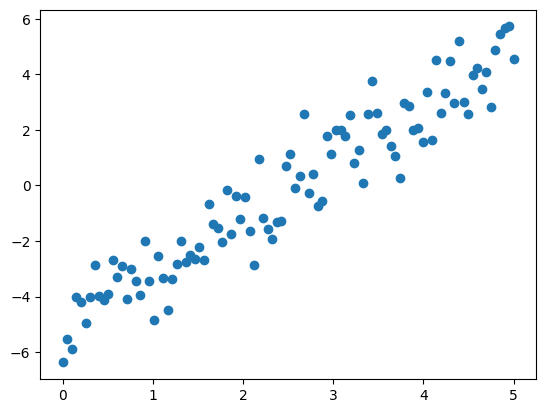

In [8]:
X = np.linspace(0, 5, 100)
y = 2 * X + (-5) + 1* np.random.randn(X.size)

# Convert to torch tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

losses = []
trajectory = []
plt.scatter(X.numpy(), y.numpy())

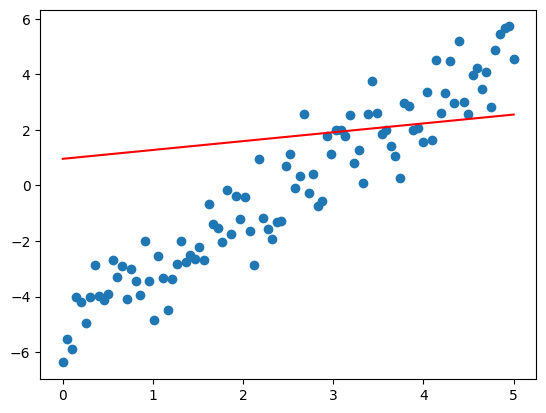

In [9]:
# initialize m and c as torch tensors with requires_grad=True
# m = torch.tensor(-8.0, requires_grad=True) # initial guess + "requires_grad=True", asks pyTorch to follow this variable and calculate the gradient of the loss function with respect to it
# c = torch.tensor(-8.0, requires_grad=True) # same as above

# randomly initialize m and c as torch tensors with requires_grad=True
m = torch.randn(1, requires_grad=True)
c = torch.randn(1, requires_grad=True)

plt.scatter(X.numpy(), y.numpy())
y_hat = (m.detach() * X + c.detach()).numpy()
plt.plot(X.numpy(), y_hat, color='red')

In [10]:
m.grad

In [11]:
def forward(m, c, X):
    return m * X + c

# loss function, least square
def loss_function(m, c, X, y):
    N = len(X)
    return (1/N) * torch.sum((y - forward(m, c, X))**2)


In [17]:
# now dldm and dldc are not needed, as we can use PyTorch's autograd to compute the gradients automatically.
eta = 0.01

# Reset logs each run
losses = []
trajectory = []

for _ in range(1000):
    loss = loss_function(m, c, X, y)
    # Store plain Python scalars (not tensor/NumPy views)
    losses.append(loss.item())
    trajectory.append((m.detach().item(), c.detach().item()))

    # Compute gradients
    loss.backward()
    print(m.data, m.grad)
    # break
    # Update parameters using gradient descent
    with torch.no_grad():
        m.data -= eta * m.grad
        c.data -= eta * c.grad

        # Zero the gradients for the next iteration
        m.grad.zero_()
        c.grad.zero_()

m, c

tensor([0.3186]) tensor([9.4840])
tensor([0.2237]) tensor([0.0294])
tensor([0.2234]) tensor([-0.1250])
tensor([0.2247]) tensor([-0.2504])
tensor([0.2272]) tensor([-0.3523])
tensor([0.2307]) tensor([-0.4348])
tensor([0.2351]) tensor([-0.5015])
tensor([0.2401]) tensor([-0.5554])
tensor([0.2456]) tensor([-0.5987])
tensor([0.2516]) tensor([-0.6335])
tensor([0.2579]) tensor([-0.6612])
tensor([0.2646]) tensor([-0.6832])
tensor([0.2714]) tensor([-0.7005])
tensor([0.2784]) tensor([-0.7140])
tensor([0.2855]) tensor([-0.7243])
tensor([0.2928]) tensor([-0.7321])
tensor([0.3001]) tensor([-0.7378])
tensor([0.3075]) tensor([-0.7419])
tensor([0.3149]) tensor([-0.7445])
tensor([0.3223]) tensor([-0.7460])
tensor([0.3298]) tensor([-0.7466])
tensor([0.3373]) tensor([-0.7465])
tensor([0.3447]) tensor([-0.7457])
tensor([0.3522]) tensor([-0.7445])
tensor([0.3596]) tensor([-0.7428])
tensor([0.3671]) tensor([-0.7409])
tensor([0.3745]) tensor([-0.7386])
tensor([0.3819]) tensor([-0.7362])
tensor([0.3892]) tenso

(tensor([1.9577], requires_grad=True), tensor([-5.0105], requires_grad=True))

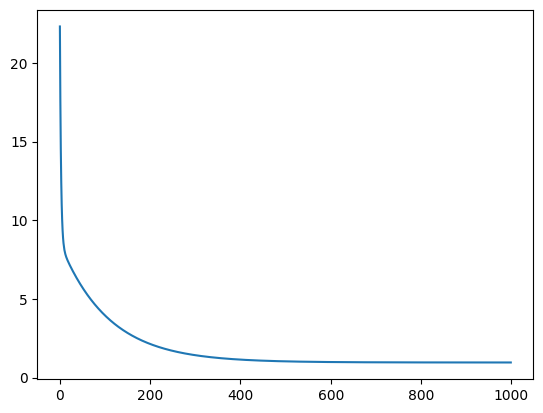

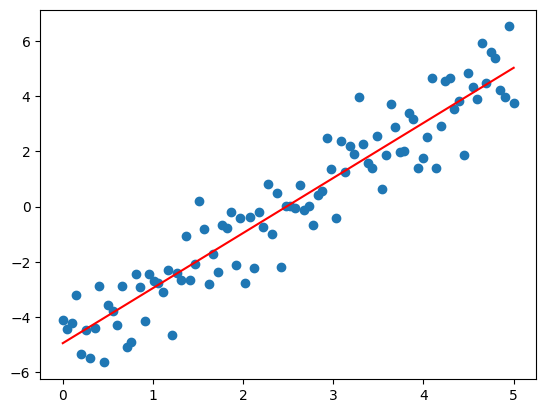

In [16]:
plt.plot(losses[:])
plt.show()

plt.scatter(X.numpy(), y.numpy())
plt.plot(X.numpy(), (m.detach() * X + c.detach()).numpy(), color='red')
plt.show()

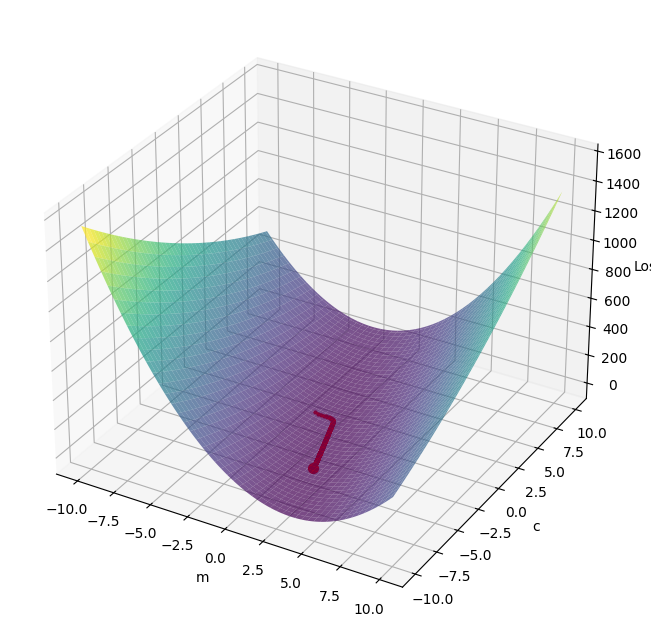

In [17]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# Create a 3D plot of the loss surface and the trajectory of the gradient descent
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create a meshgrid for m and c values
m_values = np.linspace(-10, 10, 100)
c_values = np.linspace(-10, 10, 100)
M, C = np.meshgrid(m_values, c_values)

# Calculate the loss surface
Loss_surface = np.zeros(M.shape)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        y_hat = M[i, j] * X.numpy() + C[i, j]
        Loss_surface[i, j] = np.mean((y.numpy() - y_hat) ** 2)

# Plot the loss surface
ax.plot_surface(M, C, Loss_surface, cmap='viridis', alpha=0.7)

# Plot the trajectory of the gradient descent as a connected line
traj = np.array(trajectory)
traj_losses = np.array(losses)
ax.plot(traj[:, 0], traj[:, 1], traj_losses, color='r', marker='o', markersize=2, linewidth=1.5)
# highlight the final point of the trajectory
ax.scatter(traj[-1, 0], traj[-1, 1], traj_losses[-1], color='red', s=50, label='Final Point')

# Set labels
ax.set_xlabel('m')
ax.set_ylabel('c')
ax.set_zlabel('Loss')

plt.show()

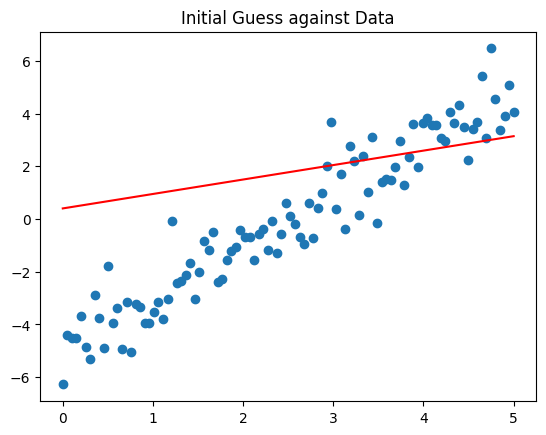

Final m: 1.9306265115737915, Final c: -4.9002366065979


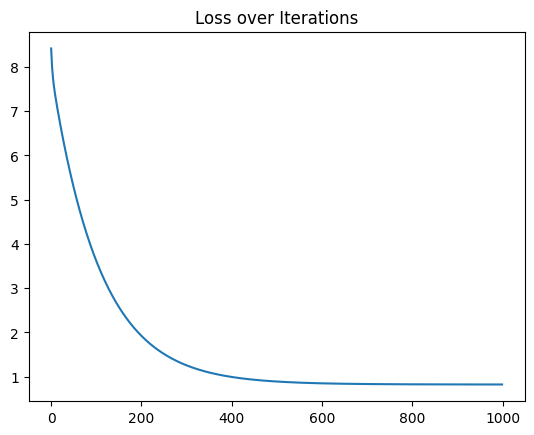

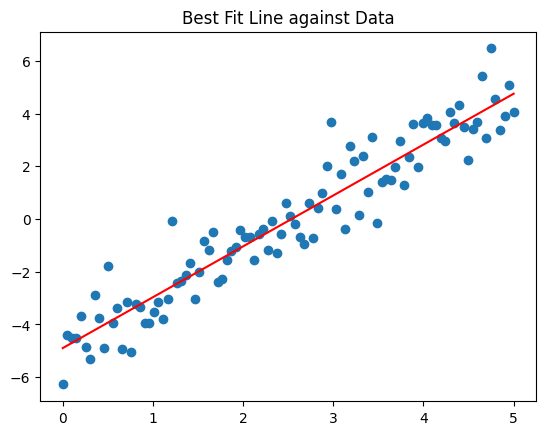

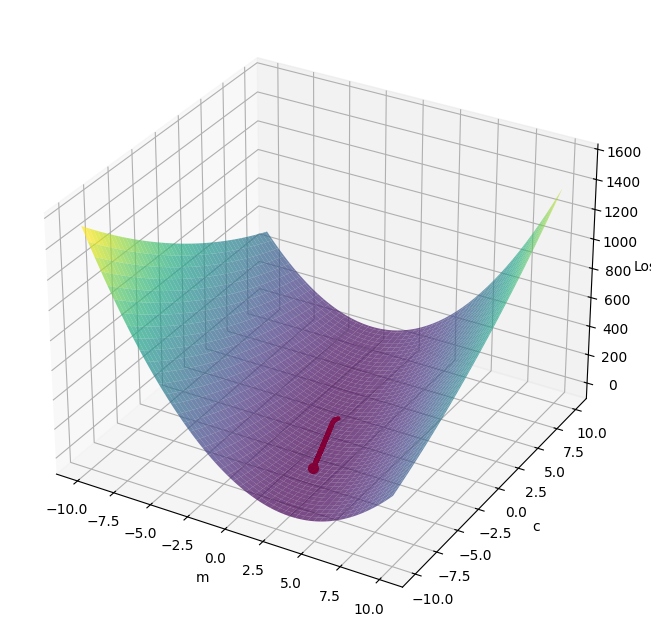

In [18]:
# putting the entire Pytorch code in one cell
import numpy as np
import matplotlib.pyplot as plt
import torch
from mpl_toolkits.mplot3d import Axes3D


X = np.linspace(0, 5, 100)
y = 2 * X + (-5) + 1* np.random.randn(X.size)

# Convert to torch tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

losses = []
trajectory = []

# randomly initialize m and c as torch tensors with requires_grad=True
m = torch.randn(1, requires_grad=True)
c = torch.randn(1, requires_grad=True)

plt.scatter(X.numpy(), y.numpy())
y_hat = (m.detach() * X + c.detach()).numpy()
plt.plot(X.numpy(), y_hat, color='red')
plt.title("Initial Guess against Data")
plt.show()

def forward(m, c, X):
    return m * X + c

# loss function, least square
def loss_function(m, c, X, y):
    N = len(X)
    return (1/N) * torch.sum((y - forward(m, c, X))**2)

# now dldm and dldc are not needed, as we can use PyTorch's autograd to compute the gradients automatically.
eta = 0.01

# Reset logs each run
losses = []
trajectory = []

for _ in range(1000):
    loss = loss_function(m, c, X, y)
    # Store plain Python scalars (not tensor/NumPy views)
    losses.append(loss.item())
    trajectory.append((m.detach().item(), c.detach().item()))

    # Compute gradients
    # this will automatically compute the gradients of the loss with respect to m and c and store them in m.grad and c.grad, 
    # Haath se differentiate karne ki zarurat nahi hai, PyTorch khud hi differentiate kar lega.

    loss.backward() 

    # Update parameters using gradient descent
    with torch.no_grad():
        m.data -= eta * m.grad
        c.data -= eta * c.grad

        # Zero the gradients for the next iteration
        m.grad.zero_() 
        c.grad.zero_()
        # ye kyon kiya? 
        #kyunki agar hum gradients ko zero nahi karenge, to agle iteration me gradients accumulate ho jayenge, aur hum galat update karenge. 
        # isliye har iteration ke baad gradients ko zero karna zaruri hai.

print(f"Final m: {m.item()}, Final c: {c.item()}")    

# vizualize the loss over iterations
plt.plot(losses[:])
plt.title("Loss over Iterations")
plt.show()

# finally plot the best fit line against the data
plt.scatter(X.numpy(), y.numpy())
y_hat = (m.detach() * X + c.detach()).numpy()
plt.plot(X.numpy(), y_hat, color='red')
plt.title("Best Fit Line against Data")
plt.show()

# fancy 3D vizualization of the loss surface and the trajectory of the gradient descent


# Create a 3D plot of the loss surface and the trajectory of the gradient descent
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create a meshgrid for m and c values
m_values = np.linspace(-10, 10, 100)
c_values = np.linspace(-10, 10, 100)
M, C = np.meshgrid(m_values, c_values)

# Calculate the loss surface
Loss_surface = np.zeros(M.shape)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        y_hat = M[i, j] * X.numpy() + C[i, j]
        Loss_surface[i, j] = np.mean((y.numpy() - y_hat) ** 2)

# Plot the loss surface
ax.plot_surface(M, C, Loss_surface, cmap='viridis', alpha=0.7)

# Plot the trajectory of the gradient descent as a connected line
traj = np.array(trajectory)
traj_losses = np.array(losses)
ax.plot(traj[:, 0], traj[:, 1], traj_losses, color='r', marker='o', markersize=2, linewidth=1.5)
# highlight the final point of the trajectory
ax.scatter(traj[-1, 0], traj[-1, 1], traj_losses[-1], color='red', s=50, label='Final Point')

# Set labels
ax.set_xlabel('m')
ax.set_ylabel('c')
ax.set_zlabel('Loss')

plt.show()

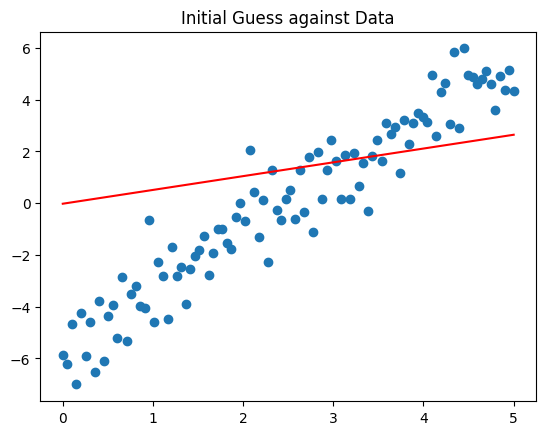

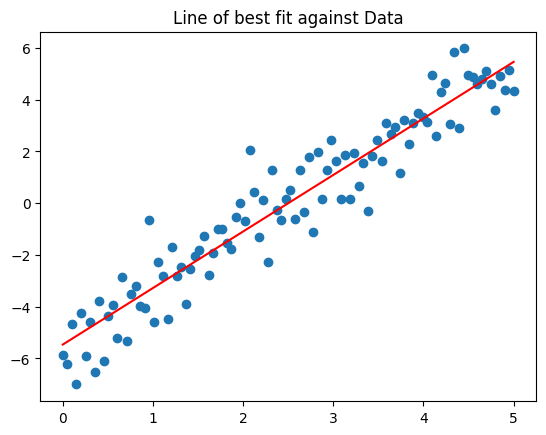

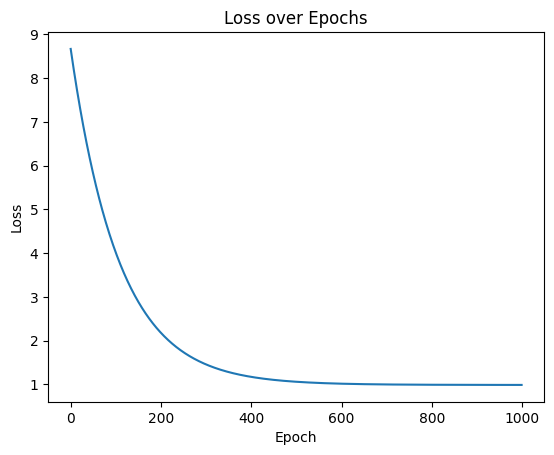

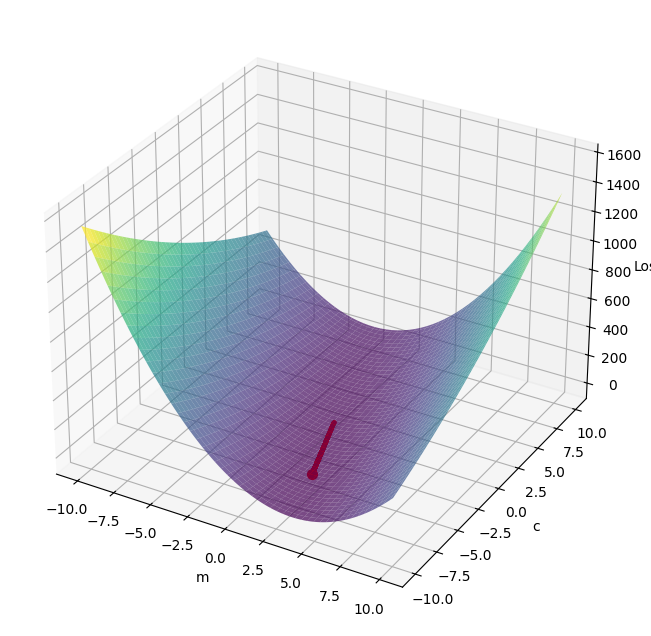

In [ ]:
# step 3: use optim so that the entire subtraction and zeroing of gradients is handled automatically by the optimizer, making the code cleaner and more efficient.
import numpy as np
import matplotlib.pyplot as plt
import torch
from mpl_toolkits.mplot3d import Axes3D


X = np.linspace(0, 5, 100)
y = 2 * X + (-5) + 1* np.random.randn(X.size)

# Convert to torch tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

losses = []
trajectory = []

# randomly initialize m and c as torch tensors with requires_grad=True
m = torch.randn(1, requires_grad=True)
c = torch.randn(1, requires_grad=True)

plt.scatter(X.numpy(), y.numpy())
y_hat = (m.detach() * X + c.detach()).numpy()
plt.plot(X.numpy(), y_hat, color='red')
plt.title("Initial Guess against Data")
plt.show()

def forward(m, c, X):
    return m * X + c

# loss function, least square
def loss_function(m, c, X, y):
    N = len(X)
    return (1/N) * torch.sum((y - forward(m, c, X))**2)

# create optimizer
optimizer = torch.optim.SGD([m, c], lr=0.01)

for epoch in range(1000):
    # forward pass
    loss = loss_function(m, c, X, y)
    
    # backward pass
    optimizer.zero_grad()
    loss.backward()
    
    # update parameters
    optimizer.step()
    
    # store loss
    losses.append(loss.item())
    trajectory.append((m.item(), c.item()))

plt.scatter(X.numpy(), y.numpy())
y_hat = (m.detach() * X + c.detach()).numpy()
plt.plot(X.numpy(), y_hat, color='red')
plt.title("Line of best fit against Data")
plt.show()

plt.plot(losses[:])
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# fancy 3D vizualization of the loss surface and the trajectory of the gradient descent

# Create a 3D plot of the loss surface and the trajectory of the gradient descent
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create a meshgrid for m and c values
m_values = np.linspace(-10, 10, 100)
c_values = np.linspace(-10, 10, 100)
M, C = np.meshgrid(m_values, c_values)

# Calculate the loss surface
Loss_surface = np.zeros(M.shape)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        y_hat = M[i, j] * X.numpy() + C[i, j]
        Loss_surface[i, j] = np.mean((y.numpy() - y_hat) ** 2)

# Plot the loss surface
ax.plot_surface(M, C, Loss_surface, cmap='viridis', alpha=0.7)

# Plot the trajectory of the gradient descent as a connected line
traj = np.array(trajectory)
traj_losses = np.array(losses)
ax.plot(traj[:, 0], traj[:, 1], traj_losses, color='r', marker='o', markersize=2, linewidth=1.5)
# highlight the final point of the trajectory
ax.scatter(traj[-1, 0], traj[-1, 1], traj_losses[-1], color='red', s=50, label='Final Point')

# Set labels
ax.set_xlabel('m')
ax.set_ylabel('c')
ax.set_zlabel('Loss')

plt.show()


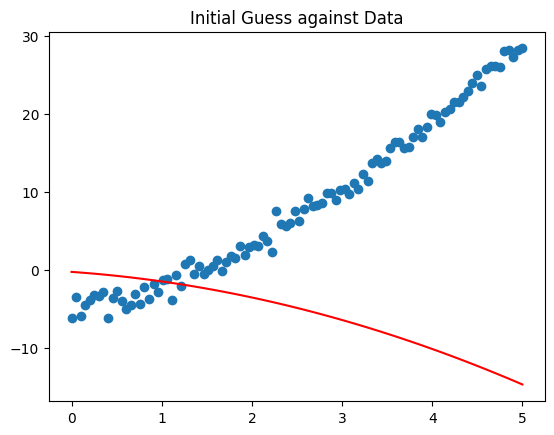

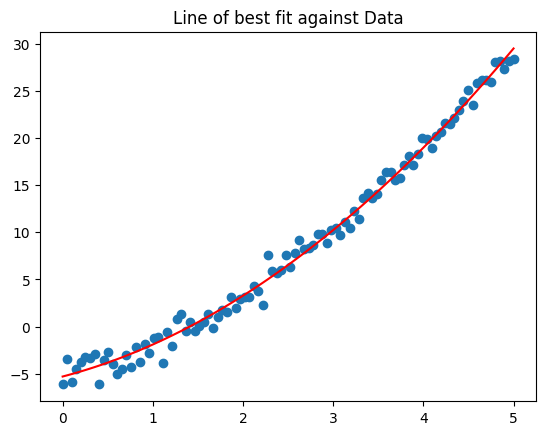

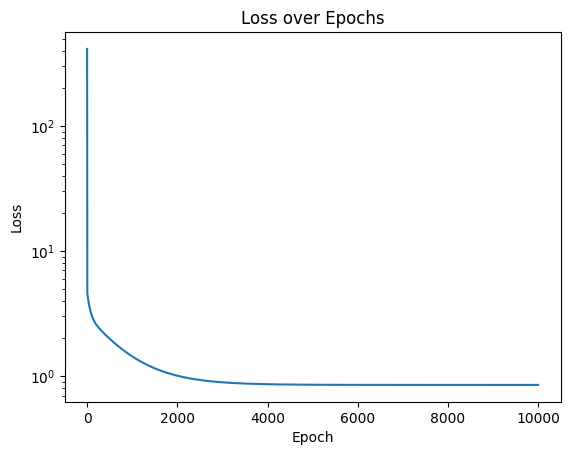

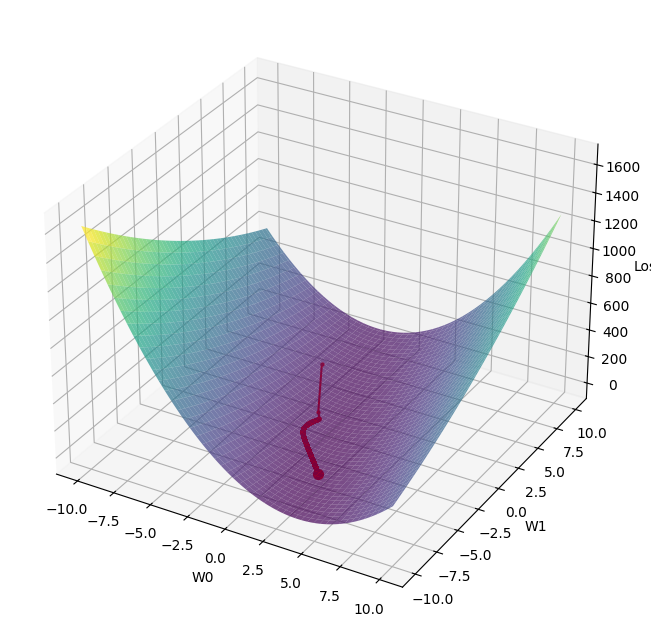

Final W0: 2.504673480987549, Final W1: -5.292617321014404, Final W2: 0.8899595737457275


In [38]:
# step 3: use optim so that the entire subtraction and zeroing of gradients is handled automatically by the optimizer, making the code cleaner and more efficient.
import numpy as np
import matplotlib.pyplot as plt
import torch
from mpl_toolkits.mplot3d import Axes3D


X = np.linspace(0, 5, 100)
y = 2 * X + (-5) +  X**2 + 1* np.random.randn(X.size)

# Convert to torch tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

losses = []
trajectory = []

# randomly initialize W as torch tensors with requires_grad=True
W = torch.randn(3, requires_grad=True)

plt.scatter(X.numpy(), y.numpy())
y_hat = (W[0].detach() * X + W[1].detach() + W[2].detach() * X**2).numpy()
plt.plot(X.numpy(), y_hat, color='red')
plt.title("Initial Guess against Data")
plt.show()

def forward(W, X):
    return W[0] * X + W[1] + W[2] * X**2

# loss function, least square
def loss_function(W, X, y):
    N = len(X)
    return (1/N) * torch.sum((y - forward(W, X))**2)

# create optimizer
optimizer = torch.optim.SGD([W], lr=0.005)

for epoch in range(10000):
    # forward pass
    loss = loss_function(W, X, y)
    
    # backward pass
    optimizer.zero_grad()
    loss.backward()
    
    # update parameters
    optimizer.step()
    
    # store loss
    losses.append(loss.item())
    trajectory.append((W[0].item(), W[1].item(), W[2].item()))

plt.scatter(X.numpy(), y.numpy())
y_hat = (W[0].detach() * X + W[1].detach() + W[2].detach() * X**2).numpy()
plt.plot(X.numpy(), y_hat, color='red')
plt.title("Line of best fit against Data")
plt.show()

plt.plot(losses[:])
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale('log')
plt.show()

# fancy 3D vizualization of the loss surface and the trajectory of the gradient descent

# Create a 3D plot of the loss surface and the trajectory of the gradient descent
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create a meshgrid for W values
W0_values = np.linspace(-10, 10, 100)
W1_values = np.linspace(-10, 10, 100)
W0, W1 = np.meshgrid(W0_values, W1_values)

# Calculate the loss surface
Loss_surface = np.zeros(W0.shape)
for i in range(W0.shape[0]):
    for j in range(W0.shape[1]):
        y_hat = W0[i, j] * X.numpy() + W1[i, j] + W[2].detach().numpy() * X.numpy()**2
        Loss_surface[i, j] = np.mean((y.numpy() - y_hat) ** 2)

# Plot the loss surface
ax.plot_surface(W0, W1, Loss_surface, cmap='viridis', alpha=0.7)

# Plot the trajectory of the gradient descent as a connected line
traj = np.array(trajectory)
traj_losses = np.array(losses)
ax.plot(traj[:, 0], traj[:, 1], traj_losses, color='r', marker='o', markersize=2, linewidth=1.5)
# highlight the final point of the trajectory
ax.scatter(traj[-1, 0], traj[-1, 1], traj_losses[-1], color='red', s=50, label='Final Point')

# Set labels
ax.set_xlabel('W0')
ax.set_ylabel('W1')
ax.set_zlabel('Loss')

plt.show()

print(f"Final W0: {W[0].item()}, Final W1: {W[1].item()}, Final W2: {W[2].item()}")


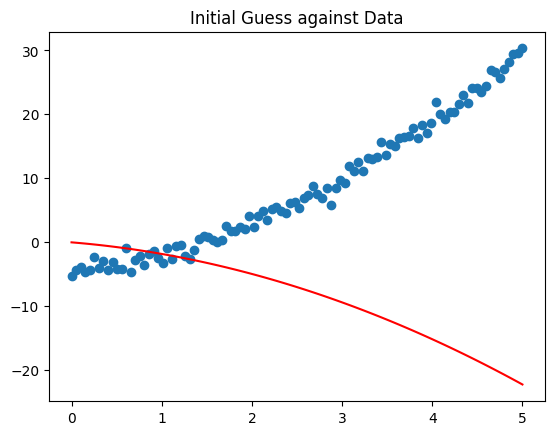

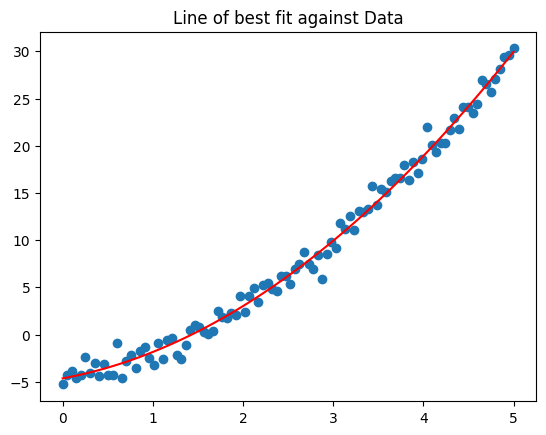

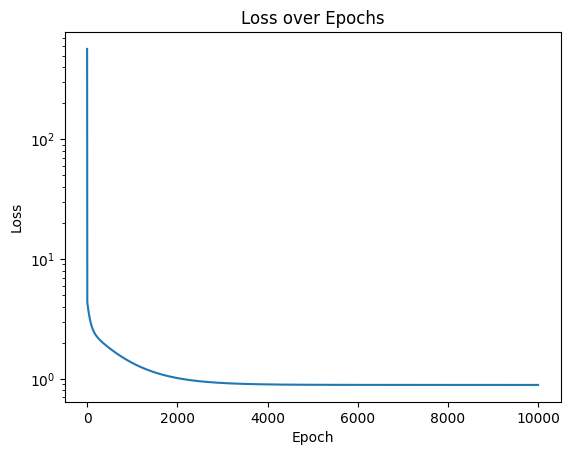

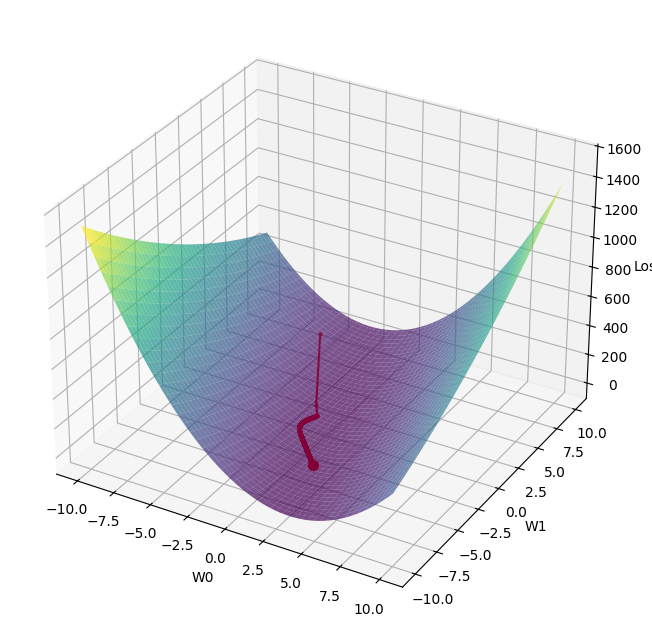

Final W0: 1.7684454917907715, Final W1: -4.6466827392578125, Final W2: 1.0301902294158936


In [18]:
# step 4, use pytorches mse instead of the loss function by hand 
import numpy as np
import matplotlib.pyplot as plt
import torch
from mpl_toolkits.mplot3d import Axes3D
from torch.nn import MSELoss


X = np.linspace(0, 5, 100)
y = 2 * X + (-5) +  X**2 + 1* np.random.randn(X.size)

# Convert to torch tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

losses = []
trajectory = []

# randomly initialize W as torch tensors with requires_grad=True
W = torch.randn(3, requires_grad=True)

plt.scatter(X.numpy(), y.numpy())
y_hat = (W[0].detach() * X + W[1].detach() + W[2].detach() * X**2).numpy()
plt.plot(X.numpy(), y_hat, color='red')
plt.title("Initial Guess against Data")
plt.show()

def forward(W, X):
    return W[0] * X + W[1] + W[2] * X**2

# loss function, least square
loss_fn = MSELoss()

# create optimizer
optimizer = torch.optim.SGD([W], lr=0.005)

for epoch in range(10000):
    # forward pass
    loss = loss_fn(forward(W, X), y)
    
    # backward pass
    optimizer.zero_grad()
    loss.backward()
    
    # update parameters
    optimizer.step()
    
    # store loss
    losses.append(loss.item())
    trajectory.append((W[0].item(), W[1].item(), W[2].item()))

plt.scatter(X.numpy(), y.numpy())
y_hat = (W[0].detach() * X + W[1].detach() + W[2].detach() * X**2).numpy()
plt.plot(X.numpy(), y_hat, color='red')
plt.title("Line of best fit against Data")
plt.show()

plt.plot(losses[:])
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale('log')
plt.show()

# fancy 3D vizualization of the loss surface and the trajectory of the gradient descent

# Create a 3D plot of the loss surface and the trajectory of the gradient descent
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create a meshgrid for W values
W0_values = np.linspace(-10, 10, 100)
W1_values = np.linspace(-10, 10, 100)
W0, W1 = np.meshgrid(W0_values, W1_values)

# Calculate the loss surface
Loss_surface = np.zeros(W0.shape)
for i in range(W0.shape[0]):
    for j in range(W0.shape[1]):
        y_hat = W0[i, j] * X.numpy() + W1[i, j] + W[2].detach().numpy() * X.numpy()**2
        Loss_surface[i, j] = np.mean((y.numpy() - y_hat) ** 2)

# Plot the loss surface
ax.plot_surface(W0, W1, Loss_surface, cmap='viridis', alpha=0.7)

# Plot the trajectory of the gradient descent as a connected line
traj = np.array(trajectory)
traj_losses = np.array(losses)
ax.plot(traj[:, 0], traj[:, 1], traj_losses, color='r', marker='o', markersize=2, linewidth=1.5)
# highlight the final point of the trajectory
ax.scatter(traj[-1, 0], traj[-1, 1], traj_losses[-1], color='red', s=50, label='Final Point')

# Set labels
ax.set_xlabel('W0')
ax.set_ylabel('W1')
ax.set_zlabel('Loss')

plt.show()

print(f"Final W0: {W[0].item()}, Final W1: {W[1].item()}, Final W2: {W[2].item()}")


In [ ]:
# Stripping out all traces of graphs, and plotting, and using pytorches mse instead of the loss function by hand 
import numpy as np
import torch
from torch.nn import MSELoss

X = np.linspace(0, 5, 100)
y = 2 * X + (-5) +  X**2 + 1* np.random.randn(X.size)
# Convert to torch tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)


# randomly initialize W as torch tensors with requires_grad=True
W = torch.randn(3, requires_grad=True)

def forward(W, X):
    return W[0] * X + W[1] + W[2] * X**2

# loss function, least square
loss_fn = MSELoss()

# create optimizer
optimizer = torch.optim.SGD([W], lr=0.005)

for epoch in range(10000):
    # forward pass
    loss = loss_fn(forward(W, X), y)

    # backward pass
    optimizer.zero_grad()
    loss.backward()
    
    # update parameters
    optimizer.step()
    
print(f"Final W0: {W[0].item()}, Final W1: {W[1].item()}, Final W2: {W[2].item()}")


Final W0: 1.8825709819793701, Final W1: -4.8576154708862305, Final W2: 1.0283482074737549


In [ ]:
# implement the above using nn.linear
import numpy as np
import torch
from torch.nn import MSELoss

X = np.array([np.linspace(0, 5, 100), np.linspace(0, 5, 100)**2]).T
y = 2 * X[:, 0] + (-5) +  X[:, 1] + 1* np.random.randn(X.shape[0])

# Convert to torch tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

# Define the model using nn.Linear
model = torch.nn.Linear(2, 1)  # 2 input features (X and X^2), 1 output feature (y)
def forward(X):
    return model(X)


# loss function, least square
loss_fn = MSELoss()

# create optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.005)

for epoch in range(20000):
    # forward pass
    y_pred = forward(X).squeeze()  # squeeze to match the shape of y
    loss = loss_fn(y_pred, y)

    # backward pass
    optimizer.zero_grad()
    loss.backward()
    
    # update parameters
    optimizer.step()

print(f"Final weights: {model.weight.data}, Final bias: {model.bias.data}")

Final weights: tensor([[2.1165, 0.9787]]), Final bias: tensor([-5.1832])


In [12]:
# evaluate the model on x = 10

model.eval()  # Set the model to evaluation mode
x_eval = torch.tensor([[10.0, 10.0**2]], dtype=torch.float32)  # Input for x=10 and x^2=100
y_eval = model(x_eval).item()  # Get the predicted value
y_eval

113.8477554321289

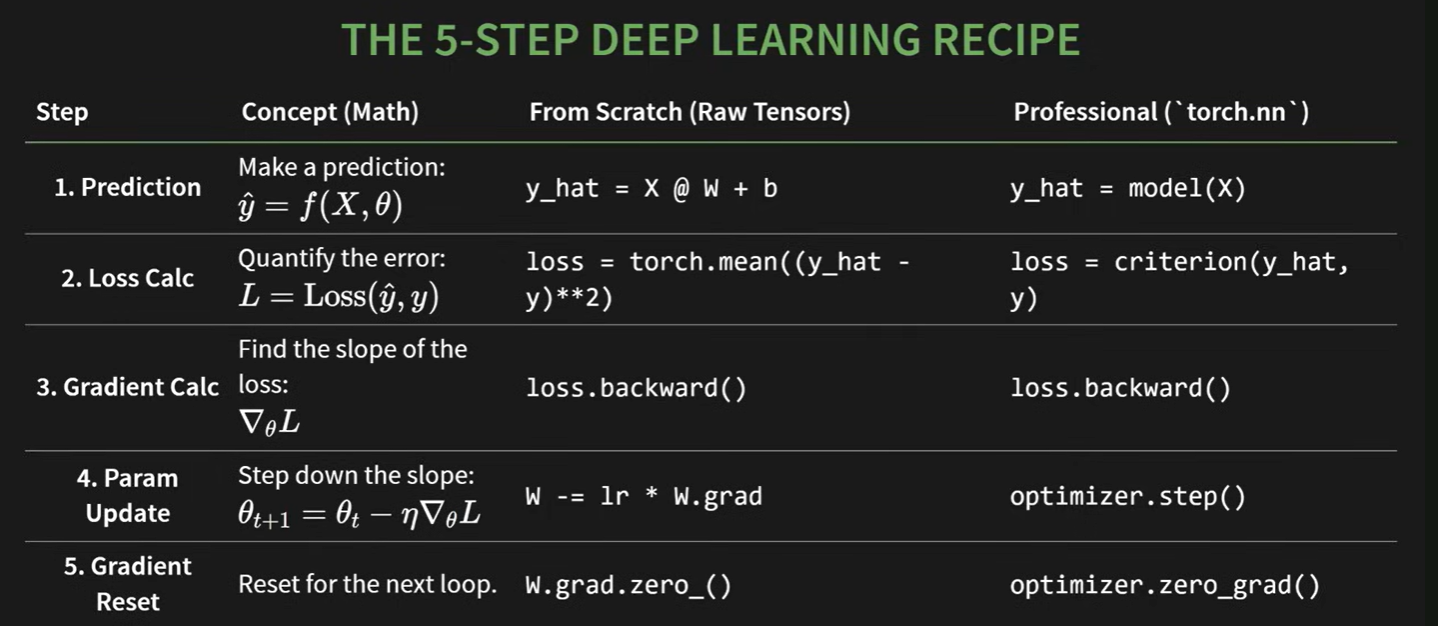

In [57]:
import numpy as np
import torch
from torch.nn import MSELoss

# heights and weights of 10 people
heights = np.array([1.47, 1.50, 1.52, 1.55, 1.57, 1.60, 1.63, 1.65, 1.68, 1.70])
weights = np.array([52.21, 53.12, 54.48, 55.84, 57.20, 58.57, 59.93, 61.29, 63.11, 64.47])
healthmarker = np.array([24.1, 23.6, 23.5, 23.3, 23.2, 22.9, 22.8, 22.7, 22.5, 22.4])
# combine into a single array of shape (10, 2)
data = np.column_stack((heights, weights))
X = torch.tensor(data, dtype=torch.float32)
y = torch.tensor(healthmarker, dtype=torch.float32)

# Define the model using nn.Linear
D_in = 2
D_out = 1

model = torch.nn.Linear(D_in, D_out)  # 2 input features (height and weight), 1 output feature (BMI)

def forward(X):
    return model(X)

# loss function, least square
loss_fn = MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

epochs = 1000


In [58]:
model

Linear(in_features=2, out_features=1, bias=True)

In [74]:
for param in model.parameters():
    print(param.data)   

tensor([[ 9.7424, -0.3045]])
tensor([25.3709])


In [71]:
for i in range(epochs):
    loss = loss_fn(forward(X).squeeze(), y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if i % 100 == 0:
        print(f"Epoch {i+1}/{epochs}, Loss: {loss.item()}")



Epoch 1/1000, Loss: 0.024569686502218246
Epoch 101/1000, Loss: 0.02454596385359764
Epoch 201/1000, Loss: 0.02450530044734478
Epoch 301/1000, Loss: 0.024637900292873383
Epoch 401/1000, Loss: 0.024441422894597054
Epoch 501/1000, Loss: 0.024439649656414986
Epoch 601/1000, Loss: 0.024377573281526566
Epoch 701/1000, Loss: 0.02434493601322174
Epoch 801/1000, Loss: 0.02431659586727619
Epoch 901/1000, Loss: 0.024281809106469154


In [82]:
s = torch.nn.Sigmoid()
s(torch.tensor([0.0, 1.0, -1.0, 3.0, -3.0]))

tensor([0.5000, 0.7311, 0.2689, 0.9526, 0.0474])

In [84]:
t = torch.nn.Tanh()
t(torch.tensor([0.0, 1.0, -1.0, 3.0, -3.0, 10, -10]))

tensor([ 0.0000,  0.7616, -0.7616,  0.9951, -0.9951,  1.0000, -1.0000])

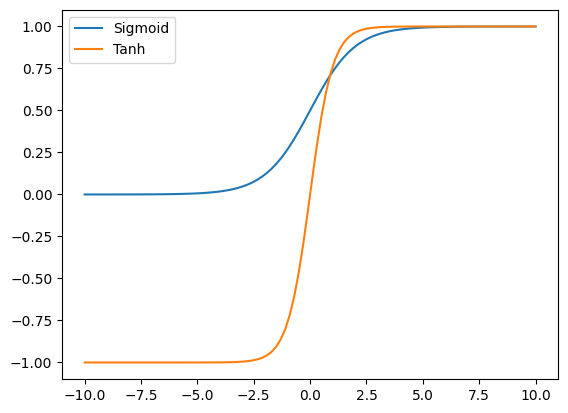

In [86]:
import matplotlib.pyplot as plt
# plot the sigmoid and tanh functions
x = torch.linspace(-10, 10, 100)
s = torch.nn.Sigmoid()
plt.plot(x.numpy(), s(x).detach().numpy(), label='Sigmoid')
t = torch.nn.Tanh()
plt.plot(x.numpy(), t(x).detach().numpy(), label='Tanh')
plt.legend()
plt.show()

In [90]:
sm = torch.nn.Softmax(dim=1)
# softmax over 8, 10, 20 and 3
sm(torch.tensor([[6.0, 6.1, 6.4, 6.0]]))

tensor([[0.2175, 0.2404, 0.3245, 0.2175]])

# neural networks

In [105]:
# iris dataset, 4 features, 3 classes, 150 samples
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import torch
from torch.nn import CrossEntropyLoss

data = load_iris()
X = data.data
y = data.target

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

# convert to torch tensors
Xtrain = torch.tensor(Xtrain, dtype=torch.float32)
ytrain = torch.tensor(ytrain, dtype=torch.long)
Xtest = torch.tensor(Xtest, dtype=torch.float32)
ytest = torch.tensor(ytest, dtype=torch.long)


fc1 = torch.nn.Linear(4,10)
fc2 = torch.nn.Linear(10,5)
fc3 = torch.nn.Linear(5,3)

relu = torch.nn.ReLU()


def forward(X):
    # hidden layer 1
    h1 = fc1(X)
    h1 = relu(h1)
    # hidden layer 2
    h2 = fc2(h1)
    h2 = relu(h2)
    # output layer
    out = fc3(h2)
    # out = torch.nn.Softmax(dim=1)(out)
    return out

loss_fn = CrossEntropyLoss()

optimizer = torch.optim.Adam([{'params': fc1.parameters()},
                             {'params': fc2.parameters()},
                             {'params': fc3.parameters()}], lr=0.01)

epochs = 10000

for epoch in range(epochs):
    # forward pass
    y_pred = forward(Xtrain)
    loss = loss_fn(y_pred, ytrain)

    # backward pass
    optimizer.zero_grad()
    loss.backward()

    # update parameters
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item()}")
# classification accuracy on test set
y_pred_test = forward(Xtest)
y_pred_test_classes = torch.argmax(y_pred_test, dim=1)

accuracy = torch.sum(y_pred_test_classes == ytest).item() / len(ytest)
print(f"Test set accuracy: {accuracy*100:.2f}%")

Epoch 1/10000, Loss: 1.1611825227737427
Epoch 101/10000, Loss: 0.06927617639303207
Epoch 201/10000, Loss: 0.05496823787689209
Epoch 301/10000, Loss: 0.05104008689522743
Epoch 401/10000, Loss: 0.04886521026492119
Epoch 501/10000, Loss: 0.047713447362184525
Epoch 601/10000, Loss: 0.04740540310740471
Epoch 701/10000, Loss: 0.04685262218117714
Epoch 801/10000, Loss: 0.04672478884458542
Epoch 901/10000, Loss: 0.04672320559620857
Epoch 1001/10000, Loss: 0.04663176089525223
Epoch 1101/10000, Loss: 0.046654462814331055
Epoch 1201/10000, Loss: 0.04660620540380478
Epoch 1301/10000, Loss: 0.04661986604332924
Epoch 1401/10000, Loss: 0.04659651219844818
Epoch 1501/10000, Loss: 0.04664905369281769
Epoch 1601/10000, Loss: 0.046591632068157196
Epoch 1701/10000, Loss: 0.046589720994234085
Epoch 1801/10000, Loss: 0.046608611941337585
Epoch 1901/10000, Loss: 0.04658738523721695
Epoch 2001/10000, Loss: 0.046905096620321274
Epoch 2101/10000, Loss: 0.0465858019888401
Epoch 2201/10000, Loss: 0.04658500477671

In [106]:
# rewrite the above using nn.Sequential
import torch
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

data = load_iris()
X = data.data
y = data.target

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

# convert to torch tensors
Xtrain = torch.tensor(Xtrain, dtype=torch.float32)
ytrain = torch.tensor(ytrain, dtype=torch.long)
Xtest = torch.tensor(Xtest, dtype=torch.float32)
ytest = torch.tensor(ytest, dtype=torch.long)


model = torch.nn.Sequential(
    torch.nn.Linear(4, 10),
    torch.nn.ReLU(),
    torch.nn.Linear(10, 5),
    torch.nn.ReLU(),
    torch.nn.Linear(5, 3)
)

loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

epochs = 10000

for epoch in range(epochs):
    # forward pass
    y_pred = model(Xtrain)
    loss = loss_fn(y_pred, ytrain)

    # backward pass
    optimizer.zero_grad()
    loss.backward()

    # update parameters
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item()}")
# classification accuracy on test set
y_pred_test = model(Xtest)
y_pred_test_classes = torch.argmax(y_pred_test, dim=1)

accuracy = torch.sum(y_pred_test_classes == ytest).item() / len(ytest)
print(f"Test set accuracy: {accuracy*100:.2f}%")


Epoch 1/10000, Loss: 1.1603115797042847
Epoch 101/10000, Loss: 0.06743886321783066
Epoch 201/10000, Loss: 0.05455468222498894
Epoch 301/10000, Loss: 0.0507180355489254
Epoch 401/10000, Loss: 0.048691436648368835
Epoch 501/10000, Loss: 0.04760732501745224
Epoch 601/10000, Loss: 0.04711567610502243
Epoch 701/10000, Loss: 0.04689715430140495
Epoch 801/10000, Loss: 0.046751923859119415
Epoch 901/10000, Loss: 0.04669421166181564
Epoch 1001/10000, Loss: 0.04665614664554596
Epoch 1101/10000, Loss: 0.04663783684372902
Epoch 1201/10000, Loss: 0.04662354290485382
Epoch 1301/10000, Loss: 0.04662245512008667
Epoch 1401/10000, Loss: 0.04660901799798012
Epoch 1501/10000, Loss: 0.04717867076396942
Epoch 1601/10000, Loss: 0.04660095274448395
Epoch 1701/10000, Loss: 0.04659775272011757
Epoch 1801/10000, Loss: 0.04659659415483475
Epoch 1901/10000, Loss: 0.046593647450208664
Epoch 2001/10000, Loss: 0.04674125090241432
Epoch 2101/10000, Loss: 0.04659087955951691
Epoch 2201/10000, Loss: 0.04658951237797737

In [108]:
import torch
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

data = load_iris()
X = data.data
y = data.target

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

# convert to torch tensors
Xtrain = torch.tensor(Xtrain, dtype=torch.float32)
ytrain = torch.tensor(ytrain, dtype=torch.long)
Xtest = torch.tensor(Xtest, dtype=torch.float32)
ytest = torch.tensor(ytest, dtype=torch.long)

class IrisNet(torch.nn.Module):
    def __init__(self):
        super(IrisNet, self).__init__()
        self.fc1 = torch.nn.Linear(4, 10)
        self.fc2 = torch.nn.Linear(10, 5)
        self.fc3 = torch.nn.Linear(5, 3)
        self.relu = torch.nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x
    
model = IrisNet()
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(10000):
    # forward pass
    y_pred = model(Xtrain)
    loss = criterion(y_pred, ytrain)

    # backward pass
    optimizer.zero_grad()
    loss.backward()

    # update parameters
    optimizer.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch+1}/10000, Loss: {loss.item()}")

# classification accuracy on test set
y_pred_test = model(Xtest)
y_pred_test_classes = torch.argmax(y_pred_test, dim=1)
accuracy = torch.sum(y_pred_test_classes == ytest).item() / len(ytest)
print(f"Test set accuracy: {accuracy*100:.2f}%")

Epoch 1/10000, Loss: 1.236810326576233
Epoch 1001/10000, Loss: 0.046614401042461395
Epoch 2001/10000, Loss: 0.046585939824581146
Epoch 3001/10000, Loss: 0.04658198729157448
Epoch 4001/10000, Loss: 0.04658062011003494
Epoch 5001/10000, Loss: 0.04657971113920212
Epoch 6001/10000, Loss: 0.04661400988698006
Epoch 7001/10000, Loss: 0.04666109383106232
Epoch 8001/10000, Loss: 0.046579327434301376
Epoch 9001/10000, Loss: 0.046579208225011826
Test set accuracy: 100.00%
